In [1]:
import pandas as pd
df = pd.read_csv("../Data/clean/airbnb_cleaned.csv")
df.head()

,title,lat,lng,rating_overall,reviews_count,rating_accuracy,rating_cleanliness,rating_value,rating_location,price_breakdown_baseprice_price,...,checkout_month,checkout_day,checkout_weekday,has_rating,bedrooms,bathrooms,description_length,has_wifi,has_pool,has_pyramid_view
0,"ETERNA.Suite W Jaccuzi, Pyramids View & Balcony",29.973873,31.146603,4.95,133.0,4.96,4.92,4.92,4.79,750.00,...,6,5,4,True,1,1.0,328,True,True,False
1,king khufu suite,29.986300,31.143100,5.00,62.0,5.00,5.00,4.97,4.85,526.87,...,5,29,4,True,1,1.0,80,False,True,True
2,Akasia Pyramids View,29.978100,31.145400,4.91,176.0,4.91,4.91,4.95,4.78,193.18,...,6,29,0,True,1,1.0,98,False,False,True
3,Mountain Cave | Pyramids View & Jacuzzi,29.979090,31.146920,4.92,12.0,5.00,4.75,4.58,4.75,592.44,...,5,16,5,True,1,1.0,249,True,True,True
4,Heaven of Pyramids,29.978787,31.144191,4.71,125.0,4.74,4.61,4.80,4.66,116.10,...,5,8,4,True,1,1.0,119,False,False,True


In [2]:
df.columns.tolist()

['title',
 'lat',
 'lng',
 'rating_overall',
 'reviews_count',
 'rating_accuracy',
 'rating_cleanliness',
 'rating_value',
 'rating_location',
 'price_breakdown_baseprice_price',
 'nightly_price',
 'price_price',
 'checkin_year',
 'checkin_month',
 'checkin_day',
 'checkin_weekday',
 'checkout_year',
 'checkout_month',
 'checkout_day',
 'checkout_weekday',
 'has_rating',
 'bedrooms',
 'bathrooms',
 'description_length',
 'has_wifi',
 'has_pool',
 'has_pyramid_view']

In [3]:
print(df.isnull().sum())

title                                0
lat                                  0
lng                                  0
rating_overall                       0
reviews_count                        0
rating_accuracy                      0
rating_cleanliness                   0
rating_value                         0
rating_location                      0
price_breakdown_baseprice_price      0
nightly_price                        0
price_price                        559
checkin_year                         0
checkin_month                        0
checkin_day                          0
checkin_weekday                      0
checkout_year                        0
checkout_month                       0
checkout_day                         0
checkout_weekday                     0
has_rating                           0
bedrooms                             0
bathrooms                            0
description_length                   0
has_wifi                             0
has_pool                 

In [4]:
print(df['has_rating'].value_counts())

has_rating
True     466
False    365
Name: count, dtype: int64


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

# ──  Drop Useless Columns ──────────────────────────────────────────
df.drop(columns=[
    'title', 'has_rating', 'rating_value', 'rating_cleanliness', 'rating_value',
    'rating_location', 'rating_accuracy', 'price_price', 'nightly_price'
], inplace=True)


# ──  Helper: Evaluate Any Model ───────────────────────────────────
def evaluate(name, Y_test, Y_pred):
    mae  = mean_absolute_error(Y_test, Y_pred)
    rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))
    r2   = r2_score(Y_test, Y_pred)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : {mae:.2f}  (off by ${mae:.2f} on average)")
    print(f"  RMSE : {rmse:.2f}")
    print(f"  R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")


# ── 9. Save Models ───────────────────────────────────────────────────
# import joblib
# joblib.dump(lr,  'Models/linear_regression.pkl')
# joblib.dump(xgb, 'Models/xgboost_model.pkl')
# print("\n✅ Models saved successfully!")

In [6]:
print(df.isnull().sum())

lat                                0
lng                                0
rating_overall                     0
reviews_count                      0
price_breakdown_baseprice_price    0
checkin_year                       0
checkin_month                      0
checkin_day                        0
checkin_weekday                    0
checkout_year                      0
checkout_month                     0
checkout_day                       0
checkout_weekday                   0
bedrooms                           0
bathrooms                          0
description_length                 0
has_wifi                           0
has_pool                           0
has_pyramid_view                   0
dtype: int64


count       831.000000
mean       4634.024886
std       14262.973631
min          62.830000
25%         635.760000
50%        1773.190000
75%        3628.890000
max      284164.830000
Name: price_breakdown_baseprice_price, dtype: float64


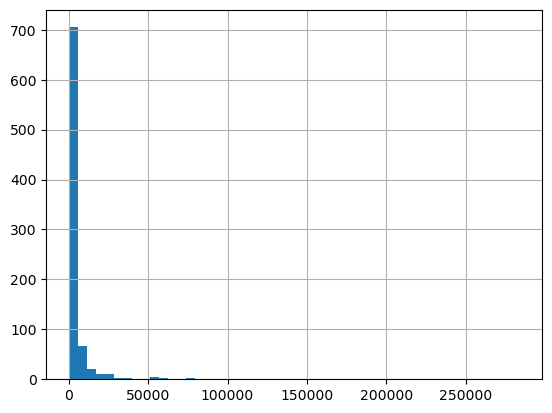

count       831.000000
mean       4634.024886
std       14262.973631
min          62.830000
25%         635.760000
50%        1773.190000
75%        3628.890000
max      284164.830000
Name: price_breakdown_baseprice_price, dtype: float64
Keeping prices between: -3854 and 8119
Rows before: 831
Rows after: 748
Column 'url' not found in DataFrame.


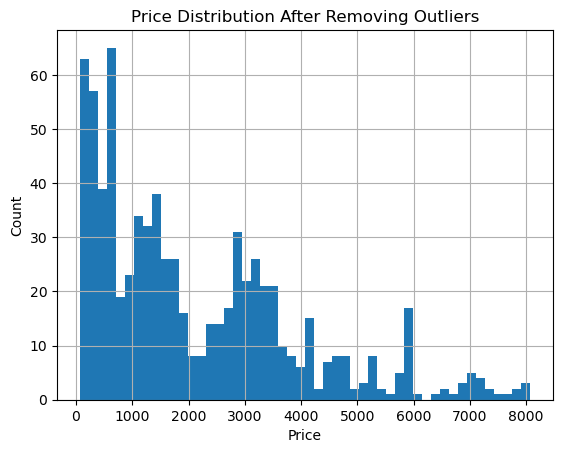

In [7]:
import matplotlib.pyplot as plt
print(df['price_breakdown_baseprice_price'].describe())
df['price_breakdown_baseprice_price'].hist(bins=50)
plt.show()

# Check the actual numbers first
print(df['price_breakdown_baseprice_price'].describe())

# Remove outliers using IQR method
Q1 = df['price_breakdown_baseprice_price'].quantile(0.25)
Q3 = df['price_breakdown_baseprice_price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Keeping prices between: {lower:.0f} and {upper:.0f}")
print(f"Rows before: {len(df)}")
df_clean = df[(df['price_breakdown_baseprice_price'] >= lower) & 
              (df['price_breakdown_baseprice_price'] <= upper)]
print(f"Rows after: {len(df_clean)}")
# Output the URL of the row with min price_breakdown_baseprice_price
if 'id' in df_clean.columns:
    min_row = df_clean.loc[df_clean['price_breakdown_baseprice_price'].idxmin()]
    print(f"URL of row with min price_breakdown_baseprice_price: {min_row['id']}")
else:
    print("Column 'url' not found in DataFrame.")
# Check new distribution
df_clean['price_breakdown_baseprice_price'].hist(bins=50)
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

In [8]:
# ──  Define X and Y ────────────────────────────────────────────────
Y = df_clean['price_breakdown_baseprice_price']
X = df_clean.drop(columns=['price_breakdown_baseprice_price'])

# ──  Train/Test Split ──────────────────────────────────────────────
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
# ──  Linear Regression ────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train, Y_train)
# Evaluate on train and test sets
Y_pred_train = lr.predict(X_train)
evaluate("Linear Regression (Train)", Y_train, Y_pred_train)
Y_pred_test = lr.predict(X_test)
evaluate("Linear Regression (Test)", Y_test, Y_pred_test)


  Linear Regression (Train)
  MAE  : 1007.83  (off by $1007.83 on average)
  RMSE : 1362.14
  R²   : 0.3699  (37.0% variance explained)

  Linear Regression (Test)
  MAE  : 1210.72  (off by $1210.72 on average)
  RMSE : 1714.93
  R²   : 0.2958  (29.6% variance explained)


In [9]:
# ──  XGBoost ──────────────────────────────────────────────────────
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)
xgb.fit(X_train, Y_train)
Y_pred_xgb = xgb.predict(X_test)
evaluate("XGBoost", Y_test, Y_pred_xgb)


  XGBoost
  MAE  : 855.70  (off by $855.70 on average)
  RMSE : 1372.81
  R²   : 0.5487  (54.9% variance explained)


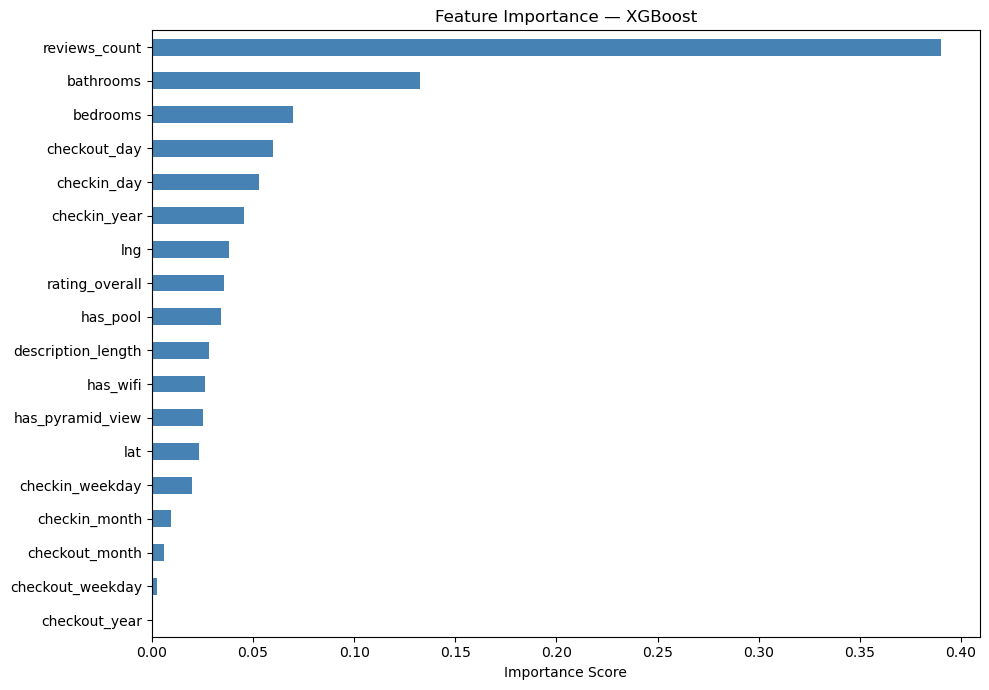


  XGBoost V2 (cleaned features) Train
  MAE  : 409.73  (off by $409.73 on average)
  RMSE : 607.27
  R²   : 0.8748  (87.5% variance explained)

  XGBoost V2 (cleaned features) Test
  MAE  : 874.86  (off by $874.86 on average)
  RMSE : 1391.09
  R²   : 0.5366  (53.7% variance explained)


In [10]:
# ──  Feature Importance (XGBoost) ─────────────────────────────────
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(10, 7), color='steelblue')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()
# Drop features with near-zero importance
# cols_to_drop = ['rating_cleanliness', 'rating_location', 
#                 'rating_accuracy', 'has_pyramid_view', 'rating_value']

# X_train_v2 = X_train.drop(columns=cols_to_drop)
# X_test_v2  = X_test.drop(columns=cols_to_drop)

xgb_v2 = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_v2.fit(X_train, Y_train)

# Evaluate on train and test sets
Y_pred_train = xgb_v2.predict(X_train)
evaluate("XGBoost V2 (cleaned features) Train", Y_train, Y_pred_train)
Y_pred_test = xgb_v2.predict(X_test)
evaluate("XGBoost V2 (cleaned features) Test", Y_test, Y_pred_test)

In [11]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, Y_train)

# Evaluate on train and test sets
Y_pred_train = rf.predict(X_train)
evaluate("Random Forest Train", Y_train, Y_pred_train)
Y_pred_test = rf.predict(X_test)
evaluate("Random Forest Test", Y_test, Y_pred_test)

# Gradient Boosting
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, Y_train)

Y_pred_train = gb.predict(X_train)
evaluate("Gradient Boosting Train", Y_train, Y_pred_train)
Y_pred_test = gb.predict(X_test)
evaluate("Gradient Boosting Test", Y_test, Y_pred_test)

# import joblib
# import os

# os.makedirs('Models', exist_ok=True)

# joblib.dump(xgb, 'Models/xgboost_model.pkl')
# joblib.dump(lr,  'Models/linear_regression.pkl')

# # Also save the feature columns for Streamlit later
# import json
# with open('Models/feature_columns.json', 'w') as f:
#     json.dump(X_train.columns.tolist(), f)

# print("✅ Models saved!")


  Random Forest Train
  MAE  : 263.28  (off by $263.28 on average)
  RMSE : 402.33
  R²   : 0.9450  (94.5% variance explained)

  Random Forest Test
  MAE  : 844.67  (off by $844.67 on average)
  RMSE : 1355.46
  R²   : 0.5601  (56.0% variance explained)

  Gradient Boosting Train
  MAE  : 508.85  (off by $508.85 on average)
  RMSE : 753.79
  R²   : 0.8071  (80.7% variance explained)

  Gradient Boosting Test
  MAE  : 899.21  (off by $899.21 on average)
  RMSE : 1404.40
  R²   : 0.5277  (52.8% variance explained)
